# LoRA Project — Run Sequence

Works in Google Colab (GPU runtime) or Jupyter Lab. Run cells top to bottom, in order — each is its own cell deliberately, so a disconnect mid-run doesn't lose earlier results.

## 1. Get the code

In [1]:
!git clone https://github.com/gabrielchan22/LoRA_PubMedRCT.git
%cd LoRA_PubMedRCT

Cloning into 'LoRA_PubMedRCT'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 21 (delta 6), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 12.00 KiB | 3.00 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/LoRA_PubMedRCT


## 2. Install dependencies

In [2]:
!pip install -r requirements.txt

In [3]:
!pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


## 3. (Colab only) Mount Drive for persistence
Skip this cell entirely in Jupyter Lab — local disk already persists, just set `CHECKPOINT_DIR = "checkpoints"` instead.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = '/content/drive/MyDrive/lora_checkpoints'

Mounted at /content/drive


## 4. Sanity-check the data pipeline
Check shapes to ensure they are correct

In [5]:
from data import build_dataloaders
from model import MODEL_NAME

train_loader, val_loader, test_loader = build_dataloaders(MODEL_NAME, batch_size=64)
batch = next(iter(train_loader))
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("labels:", batch["labels"].shape)

README.md:   0%|          | 0.00/646 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

train.jsonl: reconstructing file:   0%|          |  0.00B / 40.7MB            

train.jsonl: downloading bytes:           |  0.00B            

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/176642 [00:00<?, ? examples/s]

Map:   0%|          | 0/29672 [00:00<?, ? examples/s]

Map:   0%|          | 0/29578 [00:00<?, ? examples/s]

input_ids: torch.Size([64, 128])
attention_mask: torch.Size([64, 128])
labels: torch.Size([64])


## 5. Run the full fine-tune baseline


In [6]:
import torch
from run_experiments import run_baseline

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

run_baseline(device, train_loader, val_loader, test_loader, checkpoint_dir=CHECKPOINT_DIR)

device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[full_finetune] epoch 2/3 val_accuracy=0.8807 val_macro_f1=0.8194


[full_finetune] epoch 3/3:   0%|          | 0/2761 [00:00<?, ?it/s]

[full_finetune] epoch 3/3 val_accuracy=0.8822 val_macro_f1=0.8225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

baseline done: {'accuracy': 0.8736560940742493, 'macro_f1': 0.8139706968167222, 'wall_clock_sec': 3416.7204761505127, 'peak_memory_mb': 4847.55908203125, 'checkpoint_size_mb': 475.52396869659424, 'trainable_params': 124649477, 'total_params': 124649477, 'trainable_pct': 100.0, 'method': 'full_finetune', 'rank': None, 'alpha_mode': None}


## 6. Run the LoRA sweep, on a subsampled training set
The full 177k-row set across 10 configs would take very very long — 25k rows keeps each run to a few minutes while still showing the rank/scaling trend. To get a better understanding and comparisons b/w baseline and LoRA performance, would do the full sweep on the entire dataset

In [7]:
from torch.utils.data import DataLoader
from run_experiments import run_lora_sweep

small_dataset = train_loader.dataset.select(range(25000))
small_train_loader = DataLoader(small_dataset, batch_size=train_loader.batch_size, shuffle=True)

run_lora_sweep(device, small_train_loader, val_loader, test_loader, epochs=1, checkpoint_dir=CHECKPOINT_DIR)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[lora_r4_alpha_over_r] epoch 1/1:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0c5c1b1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0c5c1b1580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

[lora_r4_alpha_over_r] epoch 1/1 val_accuracy=0.8498 val_macro_f1=0.7850


...

[lora_r64_alpha_over_r] epoch 1/1 val_accuracy=0.8288 val_macro_f1=0.7603
lora_r64_alpha_over_r done: {'accuracy': 0.8209480047225952, 'macro_f1': 0.7521378399092233, 'wall_clock_sec': 295.84769225120544, 'peak_memory_mb': 3104.65673828125, 'checkpoint_size_mb': 11.285754203796387, 'trainable_params': 2953733, 'total_params': 127008773, 'trainable_pct': 2.325613365306663, 'method': 'lora', 'rank': 64, 'alpha_mode': 'alpha_over_r'}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[lora_r64_alpha_over_sqrt_r] epoch 1/1:   0%|          | 0/391 [00:00<?, ?it/s]

[lora_r64_alpha_over_sqrt_r] epoch 1/1 val_accuracy=0.3353 val_macro_f1=0.1004
lora_r64_alpha_over_sqrt_r done: {'accuracy': 0.3341672718524933, 'macro_f1': 0.10018752217322995, 'wall_clock_sec': 294.61325573921204, 'peak_memory_mb': 3104.65673828125, 'checkpoint_size_mb': 11.286091804504395, 'trainable_params': 2953733, 'total_params': 127008773, 'trainable_pct': 2.325613365306663, 'method': 'lora', 'rank': 64, 'alpha_mode': 'alpha_over_sqrt_r'}


## 7. Build the results table and generate plots

In [8]:
from run_experiments import build_results_table

df = build_results_table()
df

,accuracy,macro_f1,wall_clock_sec,peak_memory_mb,checkpoint_size_mb,trainable_params,total_params,trainable_pct,method,rank,alpha_mode
0,0.873656,0.813971,3416.720476,4847.559082,475.523969,124649477,124649477,100.000000,full_finetune,NaN,None
1,0.840997,0.776421,289.662616,3052.625488,2.848199,741893,124796933,0.594480,lora,4.0,alpha_over_r
2,0.831733,0.767166,293.937116,3052.625488,2.848536,741893,124796933,0.594480,lora,4.0,alpha_over_sqrt_r
3,0.845290,0.782875,293.425635,3056.094238,3.410699,889349,124944389,0.711796,lora,8.0,alpha_over_r
4,0.801339,0.725736,293.144853,3056.094238,3.411036,889349,124944389,0.711796,lora,8.0,alpha_over_sqrt_r
5,0.844141,0.781192,293.773506,3063.031738,4.535754,1184261,125239301,0.945599,lora,16.0,alpha_over_r
6,0.334167,0.100188,292.506206,3063.031738,4.536092,1184261,125239301,0.945599,lora,16.0,alpha_over_sqrt_r
7,0.840456,0.775482,294.582571,3076.906738,6.785754,1774085,125829125,1.409916,lora,32.0,alpha_over_r
8,0.334167,0.100188,292.788633,3076.906738,6.786092,1774085,125829125,1.409916,lora,32.0,alpha_over_sqrt_r
9,0.820948,0.752138,295.847692,3104.656738,11.285754,2953733,127008773,2.325613,lora,64.0,alpha_over_r


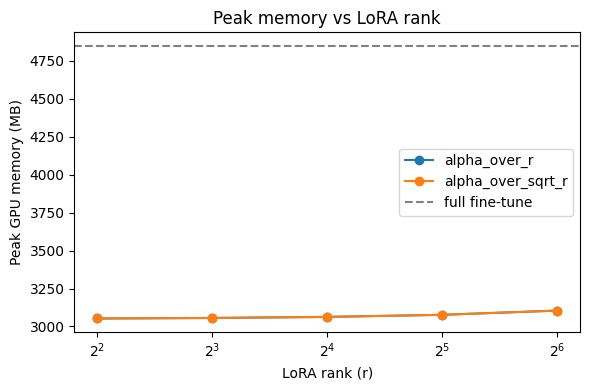

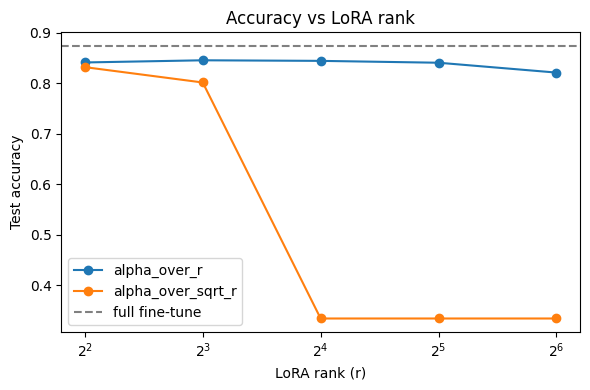

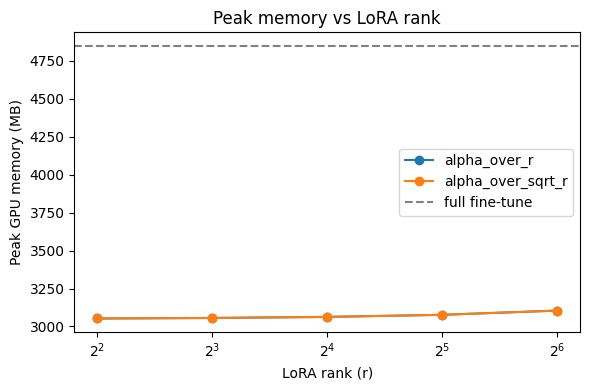

In [9]:
from plots import plot_accuracy_vs_rank, plot_memory_vs_rank

plot_accuracy_vs_rank()
plot_memory_vs_rank()

## 8. Save results


In [10]:
from google.colab import files

files.download('results.csv')
files.download('accuracy_vs_rank.png')
files.download('memory_vs_rank.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>